# MLPro — Model Screenshots
Each cell produces one screenshot-ready visual for the presentation deck.

**Final v7-Robust model**: 13 features (10 code + 3 metadata), 400 estimators, monotonic constraints, trained on 10,968 mal + 5,159 ben (2.13:1).

## 1. Setup & Load Model

In [1]:
import os, sys, json
sys.path.insert(0, '../dags')

os.environ['DB_HOST']='localhost'; os.environ['DB_PORT']='15432'
os.environ['DB_NAME']='packages'; os.environ['DB_USER']='appuser'; os.environ['DB_PASS']='apppass'

import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
import shap
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve,
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from storage.db import get_conn

mpl.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 180,
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})
print('Setup complete')

Setup complete


## 2. Load Champion Model

In [2]:
model = XGBClassifier(); model.load_model('../model/champion.json')
v1_model = XGBClassifier(); v1_model.load_model('../model/champion-v1-baseline.json')

FEATURES = [
    'entropy_max', 'has_network_in_install', 'has_credential_access',
    'has_obfuscated_code', 'has_exec_eval', 'install_script_lines',
    'dangerous_import_count', 'has_os_targeting', 'has_external_payload',
    'api_category_count', 'typosquat_distance', 'is_typosquat',
    'version_jump_suspicious',
]
V1_FEATURES = [
    'entropy_max', 'has_network_in_install', 'has_credential_access',
    'has_obfuscated_code', 'has_exec_eval', 'install_script_lines',
    'dangerous_import_count', 'has_os_targeting', 'has_external_payload',
    'api_category_count', 'typosquat_distance', 'is_typosquat',
    'has_repo_link', 'version_count', 'version_jump_suspicious',
    'description_length', 'readme_length',
]

print(f'v7-Robust: {len(FEATURES)} features, 400 trees')
print(f'v1-baseline: {len(V1_FEATURES)} features')

v7-Robust: 13 features, 400 trees
v1-baseline: 17 features


## 3. Pull Labeled Data

In [3]:
sql = '''
SELECT
    p.name, p.registry, p.label,
    COALESCE(f.entropy_max, 0)                              AS entropy_max,
    COALESCE(f.has_network_in_install::int, 0)              AS has_network_in_install,
    COALESCE(f.has_credential_access::int, 0)               AS has_credential_access,
    COALESCE(f.has_obfuscated_code::int, 0)                 AS has_obfuscated_code,
    COALESCE(f.has_exec_eval::int, 0)                       AS has_exec_eval,
    COALESCE(f.install_script_lines, 0)                     AS install_script_lines,
    COALESCE(f.dangerous_import_count, 0)                   AS dangerous_import_count,
    COALESCE(f.has_os_targeting::int, 0)                    AS has_os_targeting,
    COALESCE(f.has_external_payload::int, 0)                AS has_external_payload,
    COALESCE(f.api_category_count, 0)                       AS api_category_count,
    COALESCE(f.typosquat_distance, 0)                       AS typosquat_distance,
    CASE WHEN f.typosquat_target IS NOT NULL THEN 1 ELSE 0 END AS is_typosquat,
    COALESCE(f.has_repo_link::int, 0)                       AS has_repo_link,
    COALESCE(f.version_count, 1)                            AS version_count,
    COALESCE(f.version_jump_suspicious::int, 0)             AS version_jump_suspicious,
    COALESCE(f.description_length, 0)                       AS description_length,
    COALESCE(f.readme_length, 0)                            AS readme_length
FROM packages p JOIN features f ON f.package_id = p.id
WHERE p.label IS NOT NULL
'''
with get_conn() as conn:
    df = pd.read_sql(sql, conn)
print(f'{len(df):,} labeled samples')
print(df.label.value_counts().rename({0:'benign',1:'malicious'}).to_string())

16,127 labeled samples
label
malicious    10968
benign        5159


## 4. Metrics — Held-Out Test Set

In [4]:
X = df[FEATURES]; y = df.label.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

metrics = {
    'F1':        f1_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_prob),
}
print('=' * 50)
print(f"{'Metric':<12}{'Value':>10}")
print('=' * 50)
for k, v in metrics.items():
    print(f'{k:<12}{v:>10.4f}')
print('=' * 50)
print(f'\nTest size: {len(y_test):,} ({(y_test==1).sum():,} malicious / {(y_test==0).sum():,} benign)')
print()
print(classification_report(y_test, y_pred, target_names=['benign','malicious'], digits=4))

Metric           Value
F1              0.9013
Precision       0.9766
Recall          0.8368
ROC-AUC         0.9175

Test size: 3,226 (2,194 malicious / 1,032 benign)

              precision    recall  f1-score   support

      benign     0.7340    0.9574    0.8310      1032
   malicious     0.9766    0.8368    0.9013      2194

    accuracy                         0.8754      3226
   macro avg     0.8553    0.8971    0.8661      3226
weighted avg     0.8990    0.8754    0.8788      3226



## 5. Confusion Matrix

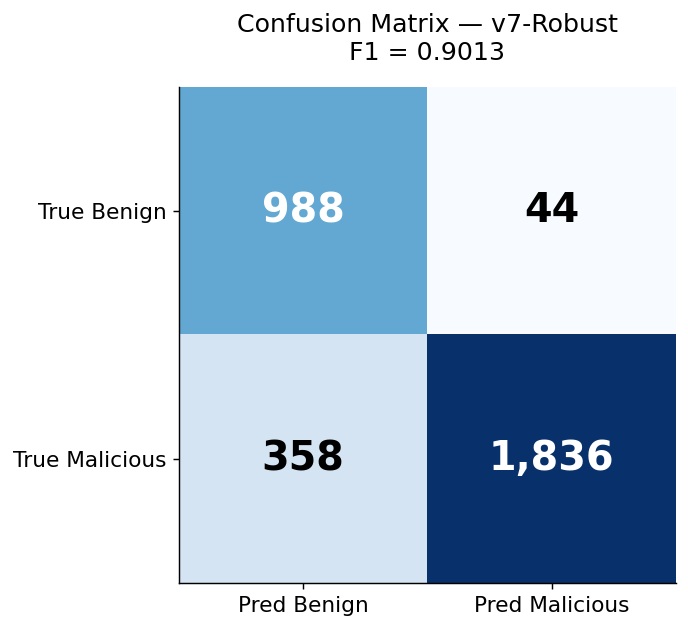


FP (benign flagged malicious): 44    FN (malicious missed): 358


In [5]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Benign','Pred Malicious'])
ax.set_yticklabels(['True Benign','True Malicious'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                color='white' if cm[i,j]>cm.max()/2 else 'black',
                fontsize=22, fontweight='bold')
ax.set_title(f'Confusion Matrix — v7-Robust\nF1 = {metrics["F1"]:.4f}', pad=15)
plt.tight_layout()
plt.savefig('../eval/screenshot_confusion_matrix.png', bbox_inches='tight', dpi=200)
plt.show()
print(f'\nFP (benign flagged malicious): {fp}    FN (malicious missed): {fn}')

## 6. ROC Curve

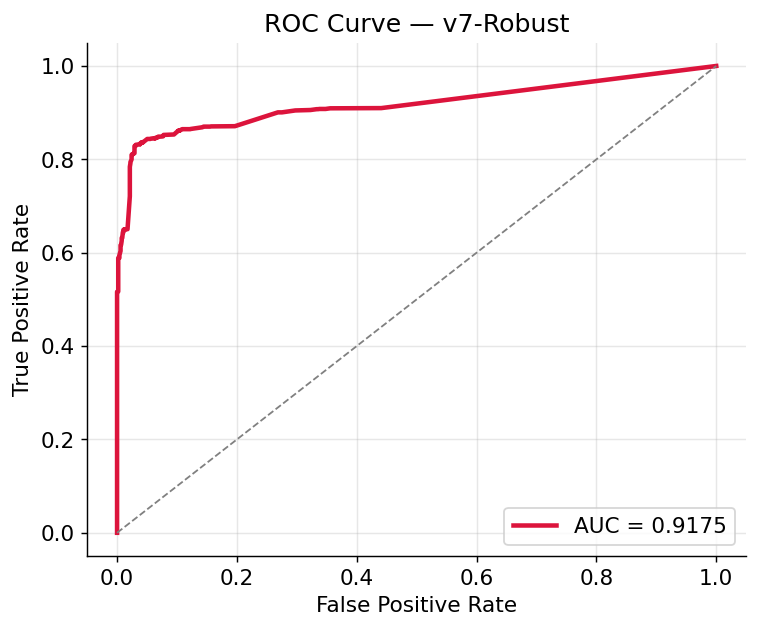

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='crimson', linewidth=2.5, label=f'AUC = {auc:.4f}')
ax.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — v7-Robust'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../eval/screenshot_roc.png', bbox_inches='tight', dpi=200)
plt.show()

## 7. Precision-Recall Curve

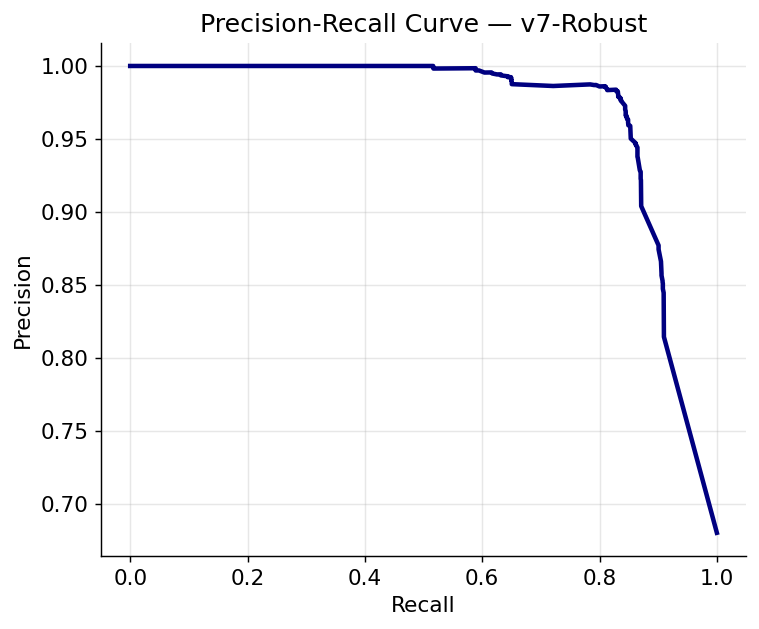

In [7]:
prec, rec, _ = precision_recall_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec, prec, color='navy', linewidth=2.5)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — v7-Robust'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../eval/screenshot_pr.png', bbox_inches='tight', dpi=200)
plt.show()

## 8. Score Distribution by Class

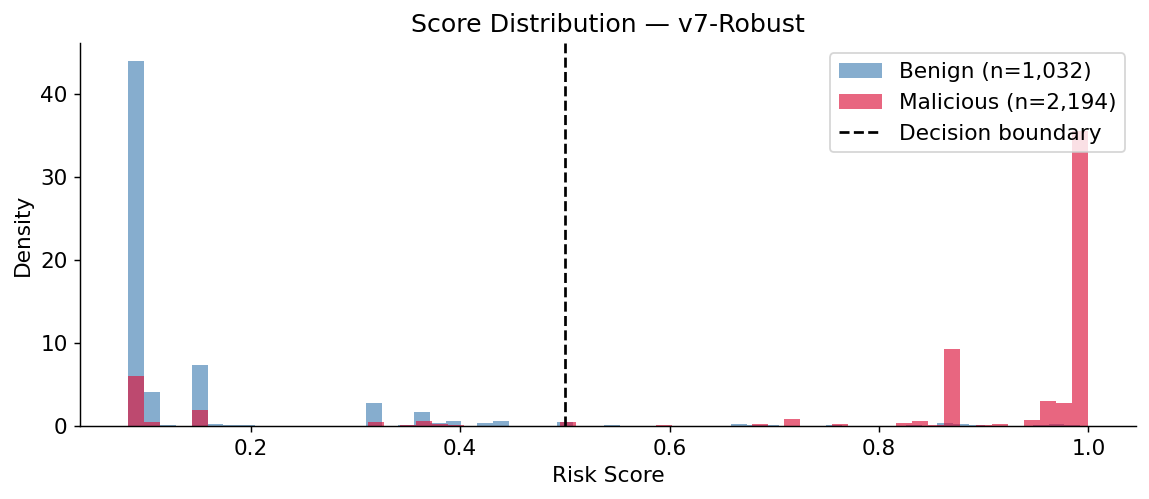

In [8]:
df_test = pd.DataFrame({'label': y_test, 'score': y_prob})
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(df_test[df_test.label==0].score, bins=60, alpha=0.65, color='steelblue',
        label=f'Benign (n={(df_test.label==0).sum():,})', density=True)
ax.hist(df_test[df_test.label==1].score, bins=60, alpha=0.65, color='crimson',
        label=f'Malicious (n={(df_test.label==1).sum():,})', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary')
ax.set_xlabel('Risk Score'); ax.set_ylabel('Density'); ax.set_title('Score Distribution — v7-Robust')
ax.legend()
plt.tight_layout()
plt.savefig('../eval/screenshot_score_dist.png', bbox_inches='tight', dpi=200)
plt.show()

## 9. SHAP Global Feature Importance

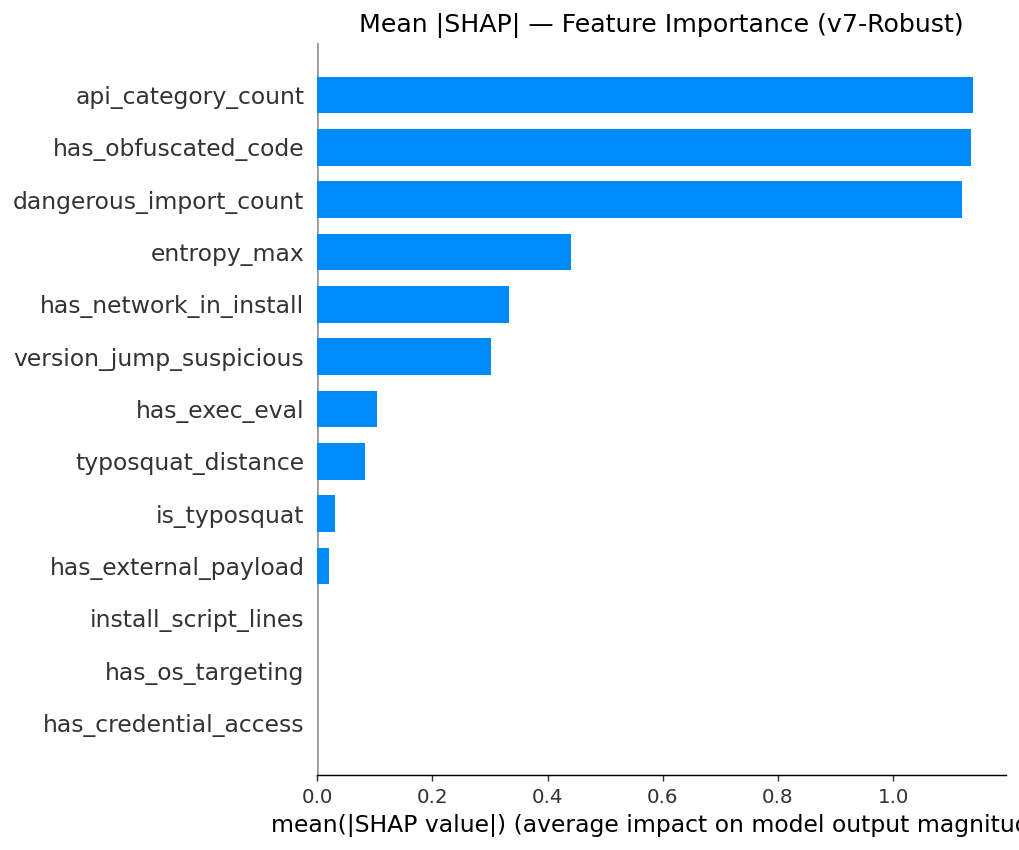

In [9]:
X_sample = X_test.sample(min(1000, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_sample)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals, X_sample, plot_type='bar', show=False)
plt.title('Mean |SHAP| — Feature Importance (v7-Robust)')
plt.tight_layout()
plt.savefig('../eval/screenshot_shap_bar.png', bbox_inches='tight', dpi=200)
plt.show()

## 10. SHAP Beeswarm

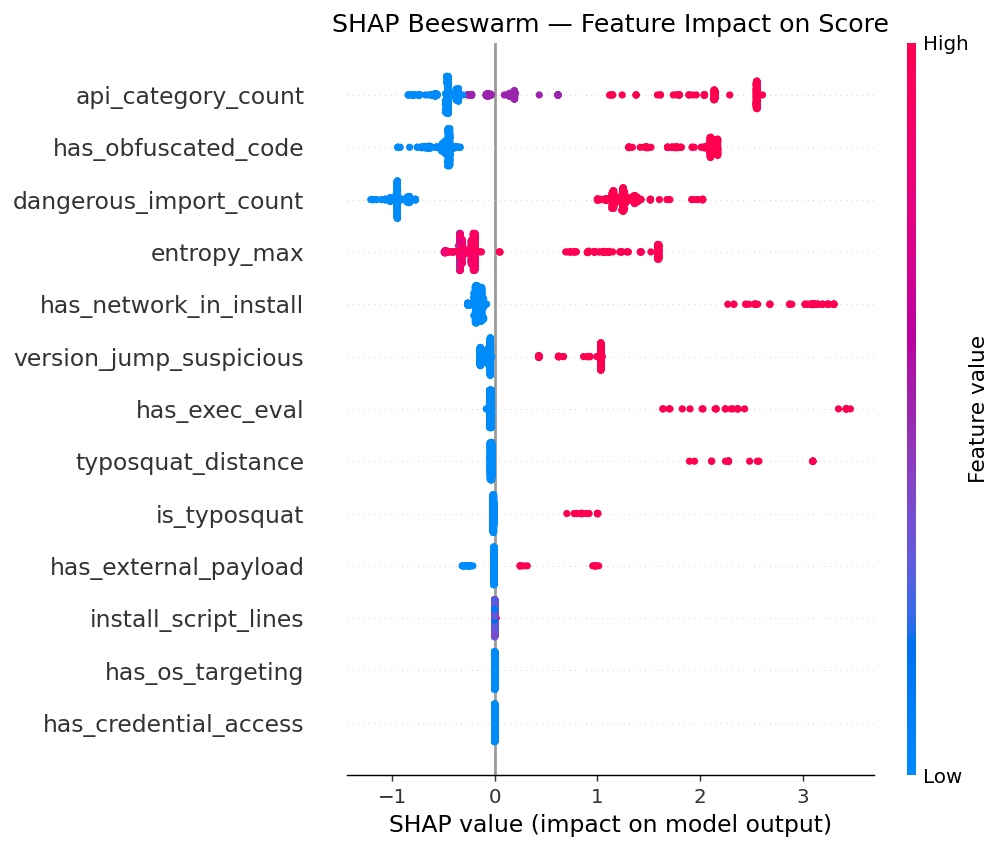

In [10]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_sample, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Score')
plt.tight_layout()
plt.savefig('../eval/screenshot_shap_beeswarm.png', bbox_inches='tight', dpi=200)
plt.show()

## 11. SHAP Waterfall — Malicious Example

Package: pypi/urklib3  Score: 0.9999



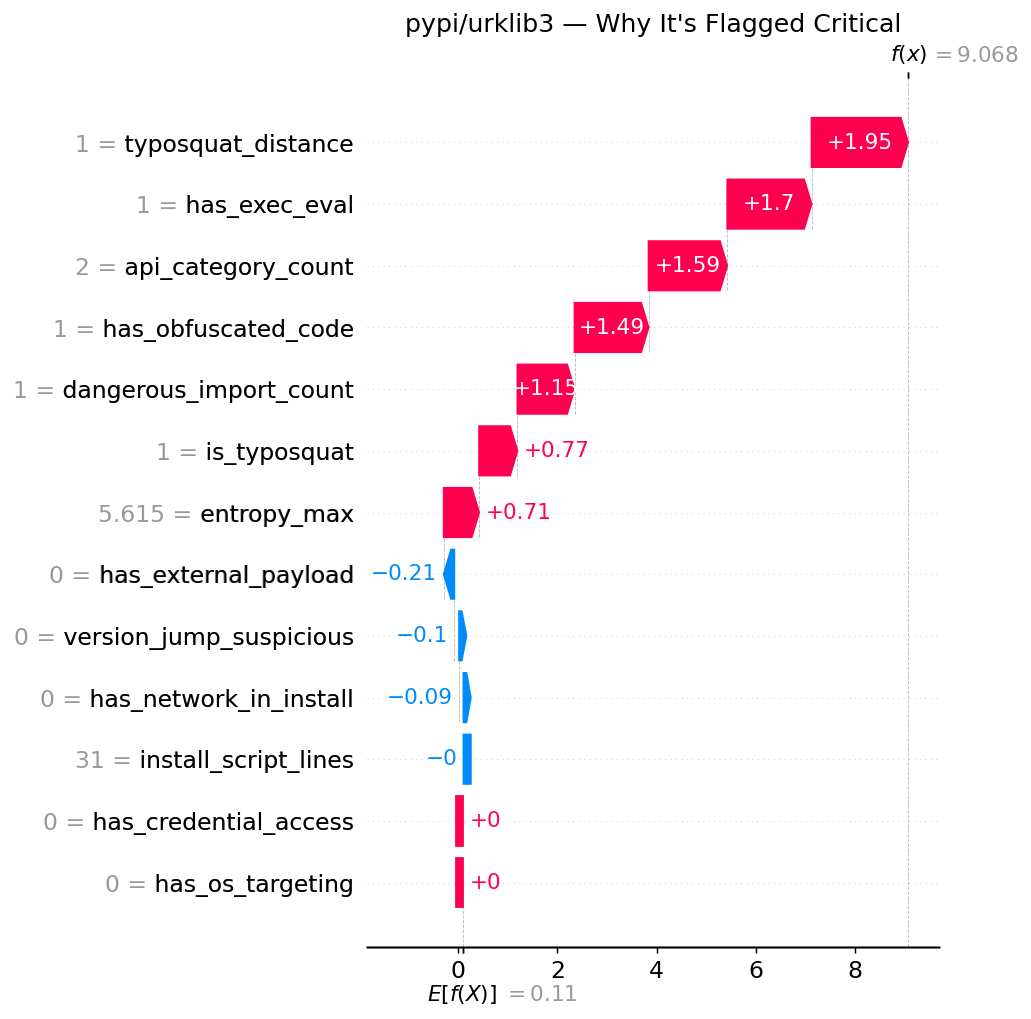

In [11]:
df_full = df.copy()
df_full['score'] = model.predict_proba(df_full[FEATURES])[:, 1]
evil = df_full[df_full.label==1].nlargest(1, 'score').iloc[0]
print(f'Package: {evil["registry"]}/{evil["name"]}  Score: {evil["score"]:.4f}\n')

x_evil = pd.DataFrame([evil[FEATURES]])
sv_evil = explainer.shap_values(x_evil)[0]
shap_exp = shap.Explanation(values=sv_evil, base_values=explainer.expected_value,
                             data=x_evil.values[0], feature_names=FEATURES)
plt.figure()
shap.plots.waterfall(shap_exp, max_display=13, show=False)
plt.title(f"{evil['registry']}/{evil['name']} — Why It's Flagged Critical")
plt.tight_layout()
plt.savefig('../eval/screenshot_shap_waterfall_malicious.png', bbox_inches='tight', dpi=200)
plt.show()

## 12. SHAP Waterfall — Benign Example

Package: pypi/visions  Score: 0.0829



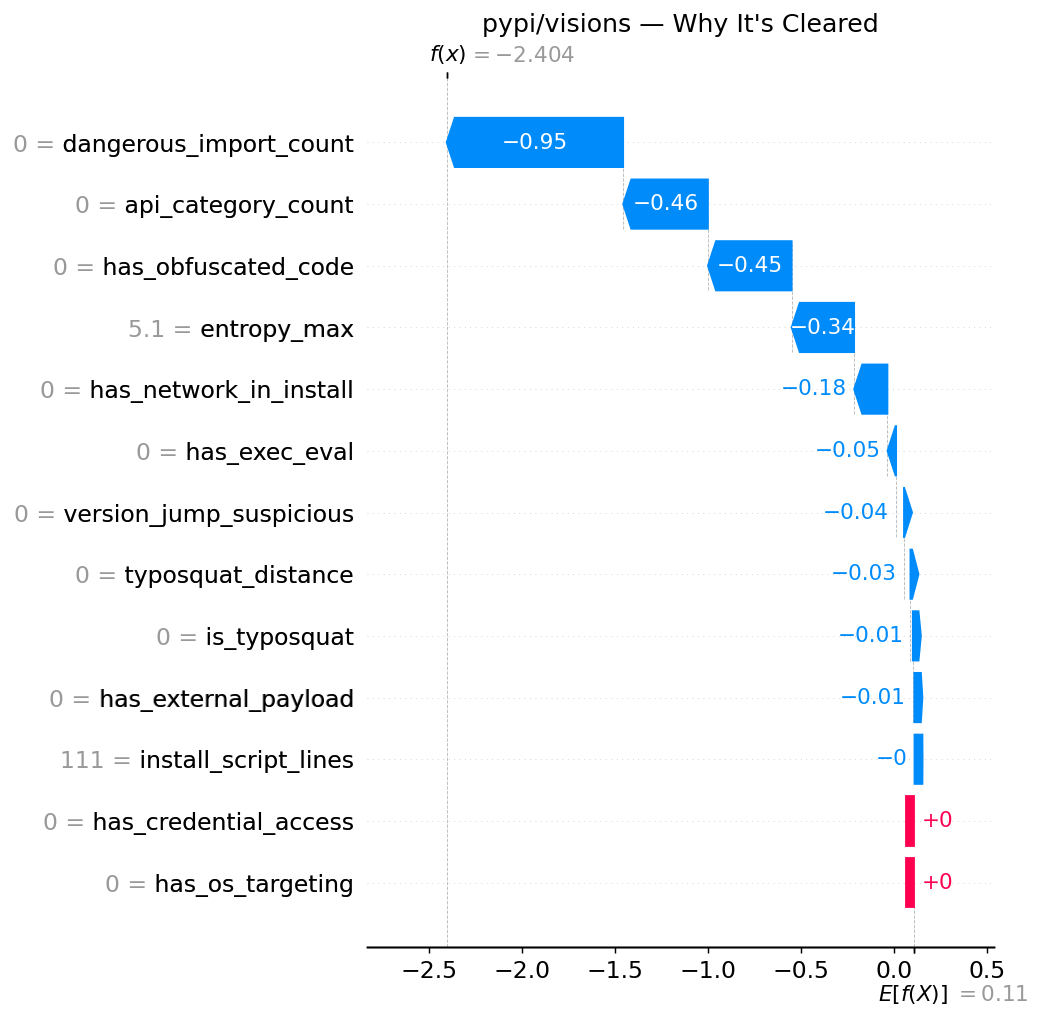

In [12]:
good = df_full[df_full.label==0].nsmallest(1, 'score').iloc[0]
print(f'Package: {good["registry"]}/{good["name"]}  Score: {good["score"]:.4f}\n')

x_good = pd.DataFrame([good[FEATURES]])
sv_good = explainer.shap_values(x_good)[0]
shap_exp_good = shap.Explanation(values=sv_good, base_values=explainer.expected_value,
                                  data=x_good.values[0], feature_names=FEATURES)
plt.figure()
shap.plots.waterfall(shap_exp_good, max_display=13, show=False)
plt.title(f"{good['registry']}/{good['name']} — Why It's Cleared")
plt.tight_layout()
plt.savefig('../eval/screenshot_shap_waterfall_benign.png', bbox_inches='tight', dpi=200)
plt.show()

## 13. Feature Distributions — Benign vs Malicious

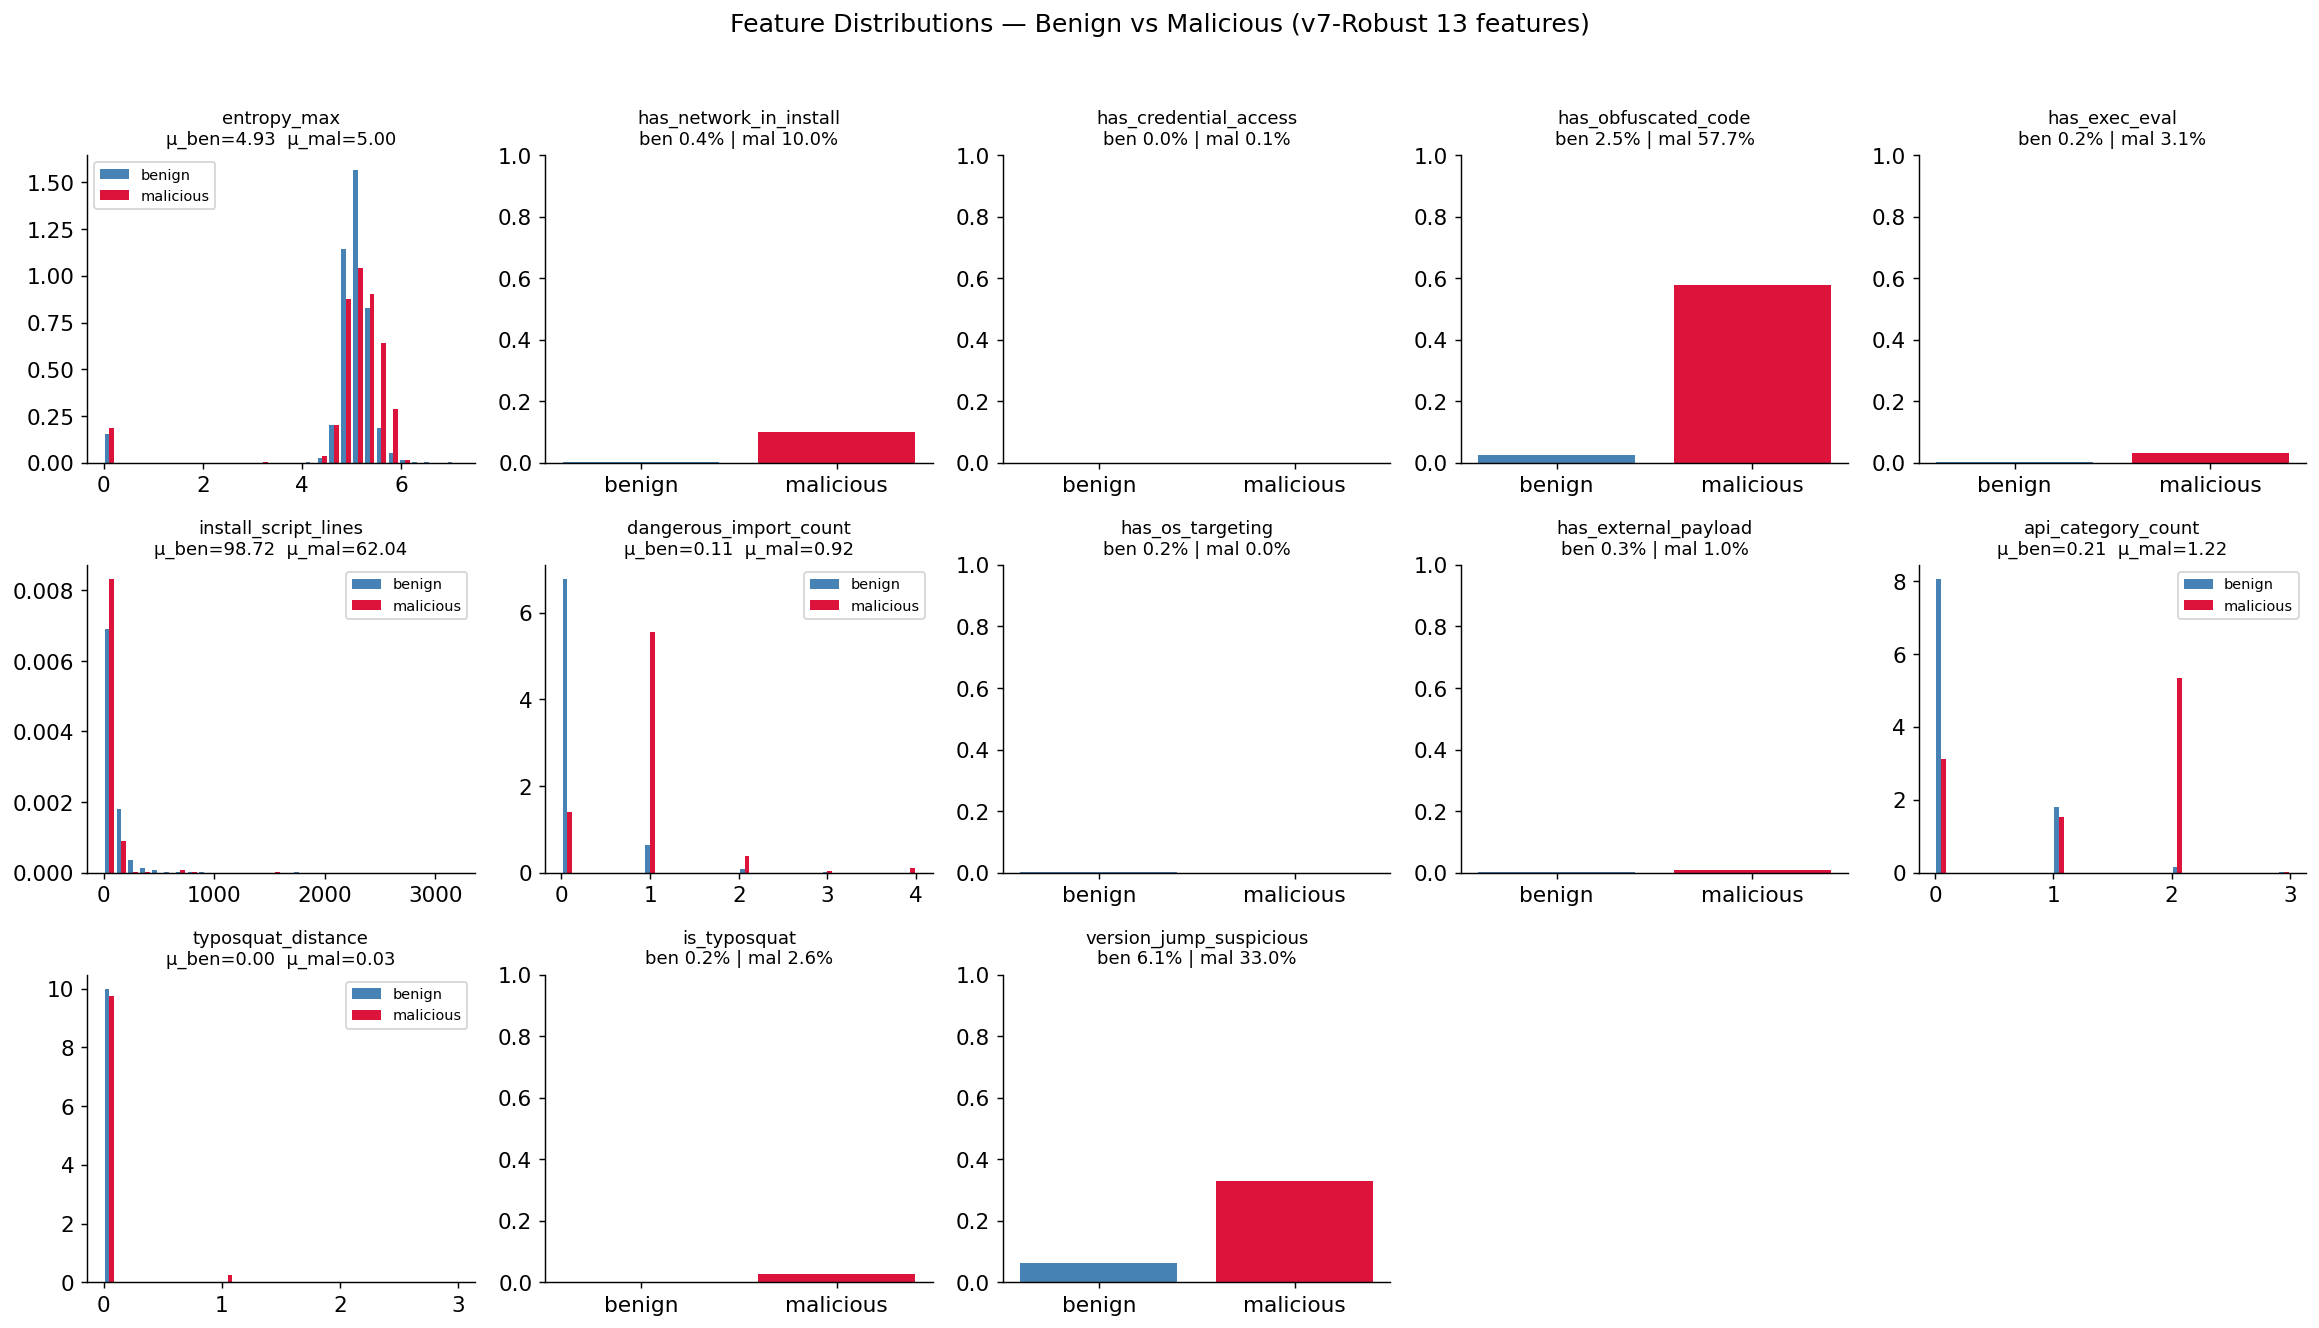

In [13]:
binary_feats = [f for f in FEATURES if df[f].isin([0,1]).all()]
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for ax, feat in zip(axes.flat, FEATURES):
    ben = df[df.label==0][feat]; mal = df[df.label==1][feat]
    if feat in binary_feats:
        br, mr = ben.mean(), mal.mean()
        ax.bar(['benign','malicious'], [br, mr], color=['steelblue','crimson'])
        ax.set_ylim(0, 1.0)
        ax.set_title(f'{feat}\nben {br:.1%} | mal {mr:.1%}', fontsize=10)
    else:
        ax.hist([ben, mal], bins=30, label=['benign','malicious'],
                color=['steelblue','crimson'], density=True)
        ax.set_title(f'{feat}\nμ_ben={ben.mean():.2f}  μ_mal={mal.mean():.2f}', fontsize=10)
        ax.legend(fontsize=8)
for ax in axes.flat[len(FEATURES):]:
    ax.axis('off')
plt.suptitle('Feature Distributions — Benign vs Malicious (v7-Robust 13 features)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../eval/screenshot_feature_distribution.png', bbox_inches='tight', dpi=180)
plt.show()

## 14. Adversarial Audit — Two Attack Classes
Greedy single-feature perturbation: attacker flips one feature toward benign without changing the malicious code itself.

In [14]:
sql_mal = '''
SELECT
    COALESCE(f.entropy_max, 0)                              AS entropy_max,
    COALESCE(f.has_network_in_install::int, 0)              AS has_network_in_install,
    COALESCE(f.has_credential_access::int, 0)               AS has_credential_access,
    COALESCE(f.has_obfuscated_code::int, 0)                 AS has_obfuscated_code,
    COALESCE(f.has_exec_eval::int, 0)                       AS has_exec_eval,
    COALESCE(f.install_script_lines, 0)                     AS install_script_lines,
    COALESCE(f.dangerous_import_count, 0)                   AS dangerous_import_count,
    COALESCE(f.has_os_targeting::int, 0)                    AS has_os_targeting,
    COALESCE(f.has_external_payload::int, 0)                AS has_external_payload,
    COALESCE(f.api_category_count, 0)                       AS api_category_count,
    COALESCE(f.typosquat_distance, 0)                       AS typosquat_distance,
    CASE WHEN f.typosquat_target IS NOT NULL THEN 1 ELSE 0 END AS is_typosquat,
    COALESCE(f.has_repo_link::int, 0)                       AS has_repo_link,
    COALESCE(f.version_count, 1)                            AS version_count,
    COALESCE(f.version_jump_suspicious::int, 0)             AS version_jump_suspicious,
    COALESCE(f.description_length, 0)                       AS description_length,
    COALESCE(f.readme_length, 0)                            AS readme_length
FROM packages p JOIN features f ON f.package_id = p.id
WHERE p.label = 1 LIMIT 500
'''
with get_conn() as conn:
    mal_df = pd.read_sql(sql_mal, conn)

def evade(mdl, feats, perturbs):
    base = mdl.predict_proba(mal_df[feats])[:, 1]
    flagged = base >= 0.3
    n_flag = int(flagged.sum())
    if n_flag == 0: return 0, 0, 0.0
    evaded = np.zeros(n_flag, dtype=bool)
    for feat, val in perturbs:
        if feat not in feats: continue
        Xp = mal_df.iloc[np.where(flagged)[0]][feats].copy()
        Xp[feat] = val
        evaded |= mdl.predict_proba(Xp)[:, 1] < 0.3
    return n_flag, int(evaded.sum()), float(evaded.mean())

TEXT = [('description_length', 120), ('readme_length', 2000)]
META = [('has_repo_link', 1), ('version_count', 8), ('is_typosquat', 0), ('typosquat_distance', 5)]

v1_text_n, v1_text_e, v1_text_r = evade(v1_model, V1_FEATURES, TEXT)
v7_text_n, v7_text_e, v7_text_r = evade(model,    FEATURES,    TEXT)
v1_meta_n, v1_meta_e, v1_meta_r = evade(v1_model, V1_FEATURES, META)
v7_meta_n, v7_meta_e, v7_meta_r = evade(model,    FEATURES,    META)

print('TEXT-PADDING attack (description / readme):')
print(f'  v1 baseline → {v1_text_e}/{v1_text_n} evaded ({v1_text_r:.1%})')
print(f'  v7-Robust   → {v7_text_e}/{v7_text_n} evaded ({v7_text_r:.1%})')
print()
print('METADATA-CLAIM attack (fake repo URL / versions):')
print(f'  v1 baseline → {v1_meta_e}/{v1_meta_n} evaded ({v1_meta_r:.1%})')
print(f'  v7-Robust   → {v7_meta_e}/{v7_meta_n} evaded ({v7_meta_r:.1%})')

TEXT-PADDING attack (description / readme):
  v1 baseline → 499/500 evaded (99.8%)
  v7-Robust   → 0/441 evaded (0.0%)

METADATA-CLAIM attack (fake repo URL / versions):
  v1 baseline → 0/500 evaded (0.0%)
  v7-Robust   → 1/441 evaded (0.2%)


## 15. Adversarial Evasion Chart

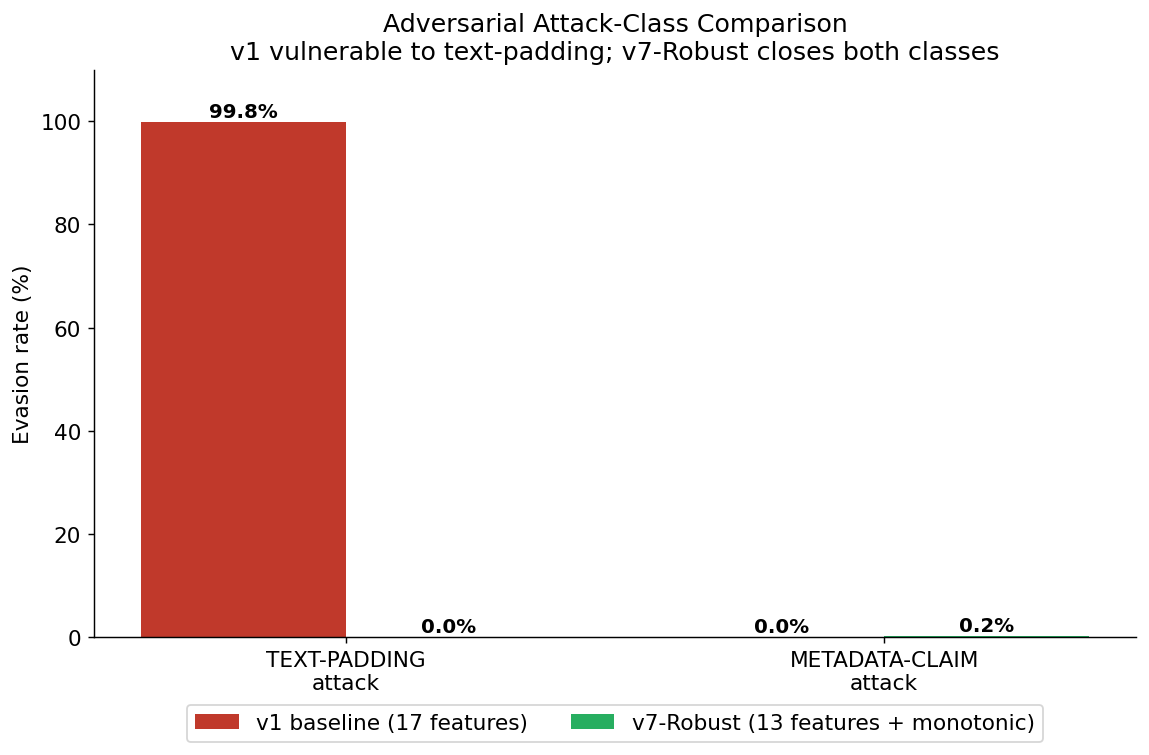

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(2); width = 0.38
ax.bar(x - width/2, [v1_text_r*100, v1_meta_r*100], width,
       label='v1 baseline (17 features)', color='#c0392b')
ax.bar(x + width/2, [v7_text_r*100, v7_meta_r*100], width,
       label='v7-Robust (13 features + monotonic)', color='#27ae60')
for i, (a, b) in enumerate([(v1_text_r, v7_text_r), (v1_meta_r, v7_meta_r)]):
    ax.text(i - width/2, a*100 + 1, f'{a:.1%}', ha='center', fontsize=11, fontweight='bold')
    ax.text(i + width/2, b*100 + 1, f'{b:.1%}', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(['TEXT-PADDING\nattack', 'METADATA-CLAIM\nattack'])
ax.set_ylabel('Evasion rate (%)')
ax.set_title('Adversarial Attack-Class Comparison\nv1 vulnerable to text-padding; v7-Robust closes both classes')
ax.set_ylim(0, 110)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=2)
plt.tight_layout()
plt.savefig('../eval/screenshot_adversarial.png', bbox_inches='tight', dpi=200)
plt.show()

## 16. Score-Drop Demo (slide-10 hero shot)

In [16]:
demo = df_full[(df_full.label==1) & (df_full.score>0.9)].iloc[0]
print(f'Demo package: {demo["registry"]}/{demo["name"]}\n')

x_orig = pd.DataFrame([demo[V1_FEATURES]])
x_pad  = x_orig.copy(); x_pad['description_length']=120; x_pad['readme_length']=2000
v1_orig = float(v1_model.predict_proba(x_orig)[0,1])
v1_pad  = float(v1_model.predict_proba(x_pad)[0,1])

x_orig_v7 = pd.DataFrame([demo[FEATURES]])
v7_orig = float(model.predict_proba(x_orig_v7)[0,1])
v7_pad  = v7_orig  # identical — text features not in v7

print('v1 baseline (17 features):')
print(f'  Original (desc=0):     {v1_orig:.4f}  CRITICAL')
print(f'  After description=120: {v1_pad:.4f}  LOW')
print(f'  Score moved: {(v1_orig-v1_pad)*100:+.1f} percentage points')
print()
print('v7-Robust (13 features):')
print(f'  Original:              {v7_orig:.4f}  CRITICAL')
print(f'  After description=120: {v7_pad:.4f}  unchanged (text features not in model)')
print(f'  Score moved: 0.0 percentage points')

Demo package: pypi/tppywvirtual

v1 baseline (17 features):
  Original (desc=0):     0.9985  CRITICAL
  After description=120: 0.0103  LOW
  Score moved: +98.8 percentage points

v7-Robust (13 features):
  Original:              0.9987  CRITICAL
  After description=120: 0.9987  unchanged (text features not in model)
  Score moved: 0.0 percentage points


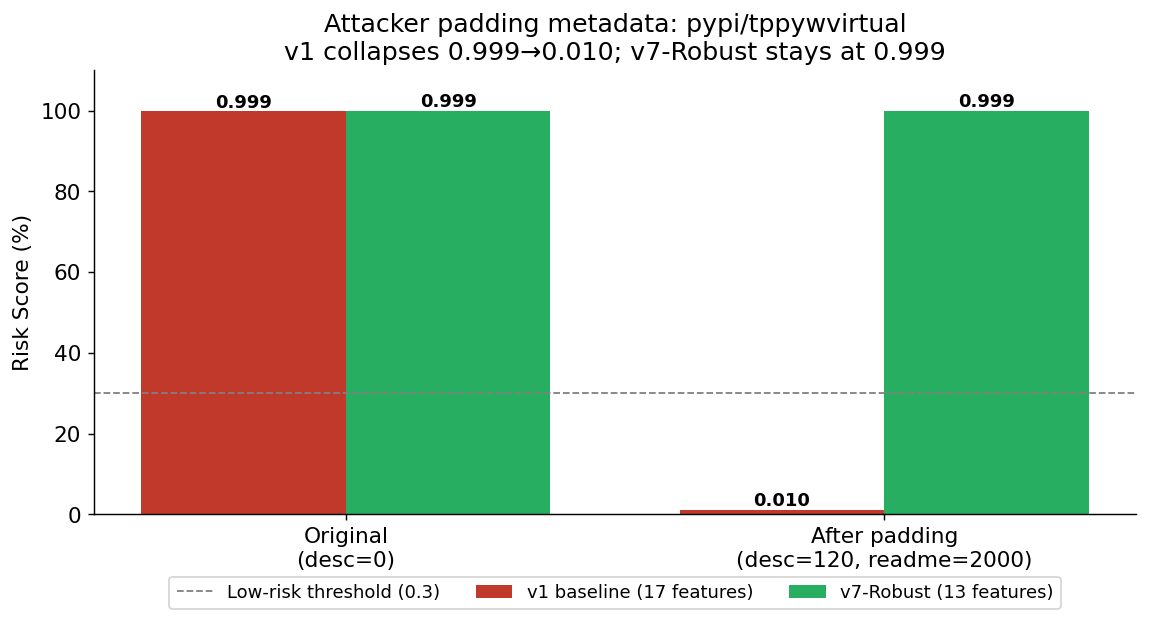

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = ['Original\n(desc=0)', 'After padding\n(desc=120, readme=2000)']
x = np.arange(2); width = 0.38
ax.bar(x - width/2, [v1_orig*100, v1_pad*100], width, color='#c0392b', label='v1 baseline (17 features)')
ax.bar(x + width/2, [v7_orig*100, v7_pad*100], width, color='#27ae60', label='v7-Robust (13 features)')
for i, (a, b) in enumerate([(v1_orig, v7_orig), (v1_pad, v7_pad)]):
    ax.text(i - width/2, a*100 + 1, f'{a:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.text(i + width/2, b*100 + 1, f'{b:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(30, color='gray', linestyle='--', linewidth=1, label='Low-risk threshold (0.3)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Risk Score (%)')
ax.set_title(f'Attacker padding metadata: {demo["registry"]}/{demo["name"]}\n'
             f'v1 collapses {v1_orig:.3f}→{v1_pad:.3f}; v7-Robust stays at {v7_orig:.3f}')
ax.set_ylim(0, 110)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=10)
plt.tight_layout()
plt.savefig('../eval/screenshot_score_drop_demo.png', bbox_inches='tight', dpi=200)
plt.show()

## 17. Live API Score (slide-9 backup)
Hits `http://localhost:8000/api/score`.

In [18]:
import requests as req

def score(registry, name, version):
    r = req.post('http://localhost:8000/api/score',
                 json={'registry':registry,'name':name,'version':version}, timeout=15)
    return r.json()

resp = score('pypi', 'craftvirtual', '10.2')
print(json.dumps(resp, indent=2))

{
  "registry": "pypi",
  "name": "craftvirtual",
  "version": "10.2",
  "score": 0.9987038373947144,
  "risk_level": "critical",
  "report_md": "# pypi/craftvirtual@10.2\n\n**Risk:** CRITICAL  |  **Score:** 0.999\n\n## Top signals\n\n- **api_category_count**: \u2191 (+2.552)\n- **has_obfuscated_code**: \u2191 (+2.092)\n- **dangerous_import_count**: \u2191 (+1.275)\n- **version_jump_suspicious**: \u2191 (+1.033)\n- **entropy_max**: \u2193 (-0.208)",
  "model_version": "3",
  "cached": true
}


## All saved screenshots

In `eval/`:
- `screenshot_confusion_matrix.png`
- `screenshot_roc.png`
- `screenshot_pr.png`
- `screenshot_score_dist.png`
- `screenshot_shap_bar.png`
- `screenshot_shap_beeswarm.png`
- `screenshot_shap_waterfall_malicious.png`
- `screenshot_shap_waterfall_benign.png`
- `screenshot_feature_distribution.png`
- `screenshot_adversarial.png`
- `screenshot_score_drop_demo.png`